In [5]:
!pip install pandas

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.8 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.8 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.8 MB 3.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 3.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.8 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.8 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.8 MB 4.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 4.4 MB/s  0:00:02
   ----------------------------------

In [9]:
import pandas as pd

df = pd.read_csv("../data/Chocolate Sales (2).csv")

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [10]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

# EDA

In [17]:
!pip install matplotlib

In [19]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Total Sales

In [23]:
total_sales = df['Amount'].sum()
# ensure Amount is numeric (remove $ and commas if present) then sum
total_sales = pd.to_numeric(df['Amount'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce').sum()
print(f'Total Sales: ${total_sales:,.2f}')

Total Sales: $19,791,571.86


In [25]:
df['Amount'] = (
    df['Amount']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sushm\AppData\Local\Temp\ipykernel_10220\4268458798.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


Product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
99% Dark & Pure         960033.45
85% Dark Bars           955268.24
Organic Choco Syrup     945345.73
Spicy Special Slims     938131.69
Mint Chip Choco         904989.55
Name: Amount, dtype: float64


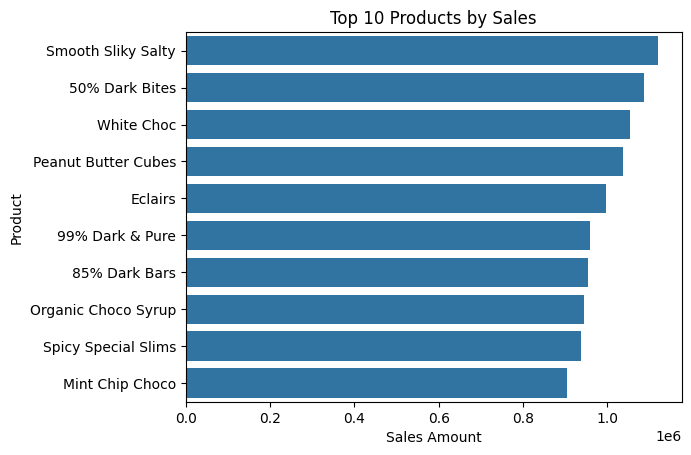

In [26]:
# Top Products
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(top_products.head(10))  # Top 10 products
sns.barplot(x=top_products.head(10).values, y=top_products.head(10).index)
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Product')
plt.show()

Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64


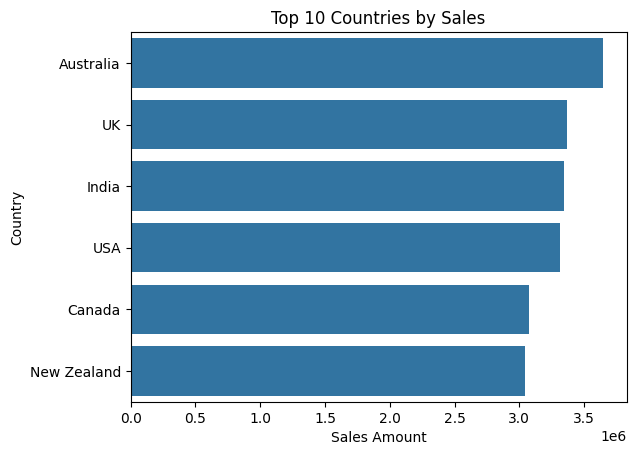

In [28]:
# Country-wise Sales
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print(country_sales.head(10))  # Top 10 countries
sns.barplot(x=country_sales.head(10).values, y=country_sales.head(10).index)
plt.title('Top 10 Countries by Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Country')
plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), dayfirst=True, errors='coerce')
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Amount'].sum()
monthly_sales.index = monthly_sales.index.astype(str)  # Convert to string for easier plotting
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

ValueError: time data "27/04/2022" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.